In [3]:
import supervision as sv
from ultralytics import YOLO, SAM
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path

Path("assets").mkdir(exist_ok=True)
urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg",    "assets/bus.jpg")
urllib.request.urlretrieve("https://ultralytics.com/images/zidane.jpg", "assets/zidane.jpg")

image = cv2.imread("assets/bus.jpg")
print(f"Imagen cargada: {image.shape}")

Imagen cargada: (1080, 810, 3)



0: 640x480 4 persons, 1 bus, 1 stop sign, 207.4ms
Speed: 37.9ms preprocess, 207.4ms inference, 7.8ms postprocess per image at shape (1, 3, 640, 480)
YOLO detectó 6 objetos


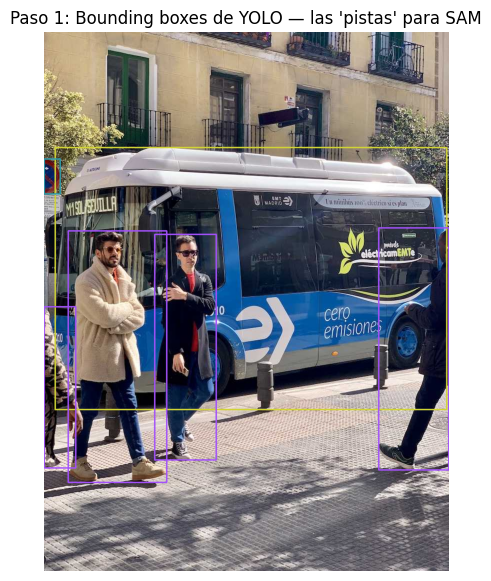

In [4]:
yolo_model = YOLO("yolov8n.pt")
yolo_results = yolo_model(image)[0]
yolo_detections = sv.Detections.from_ultralytics(yolo_results)

print(f"YOLO detectó {len(yolo_detections)} objetos")

box_annotator = sv.BoxAnnotator()
scene_yolo = box_annotator.annotate(scene=image.copy(), detections=yolo_detections)
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(scene_yolo, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Paso 1: Bounding boxes de YOLO — las 'pistas' para SAM")
plt.show()

In [5]:

sam_model = SAM("sam3.pt")
# sam3.pt ≈ 3.4 GB — incluido en ultralytics, no requiere paquete extra
# Si no se descarga automáticamente:
#   1. Solicita acceso en https://huggingface.co/facebook/sam3
#   2. Descarga sam3.pt y colócalo en la carpeta del notebook

# SAM espera una lista de Python, no un array NumPy
# .tolist() hace la conversión
bboxes = yolo_detections.xyxy.tolist()

sam_results = sam_model(image, bboxes=bboxes)[0]

# La misma función from_ultralytics() funciona para YOLO y para SAM
# — ese es el punto central de Supervision: no importa qué modelo usaste
sam_detections = sv.Detections.from_ultralytics(sam_results)

print(f"Detecciones SAM: {len(sam_detections)}")
print(f"¿Tiene máscaras? {sam_detections.mask is not None}")
if sam_detections.mask is not None:
    print(f"Shape de las máscaras: {sam_detections.mask.shape}")
    # (N_objetos, alto_imagen, ancho_imagen)
    # Cada "capa" es una máscara booleana para un objeto



WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
0: 1036x1036 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 54597.0ms
Speed: 35.8ms preprocess, 54597.0ms inference, 31.3ms postprocess per image at shape (1, 3, 1036, 1036)
Detecciones SAM: 6
¿Tiene máscaras? True
Shape de las máscaras: (6, 1080, 810)


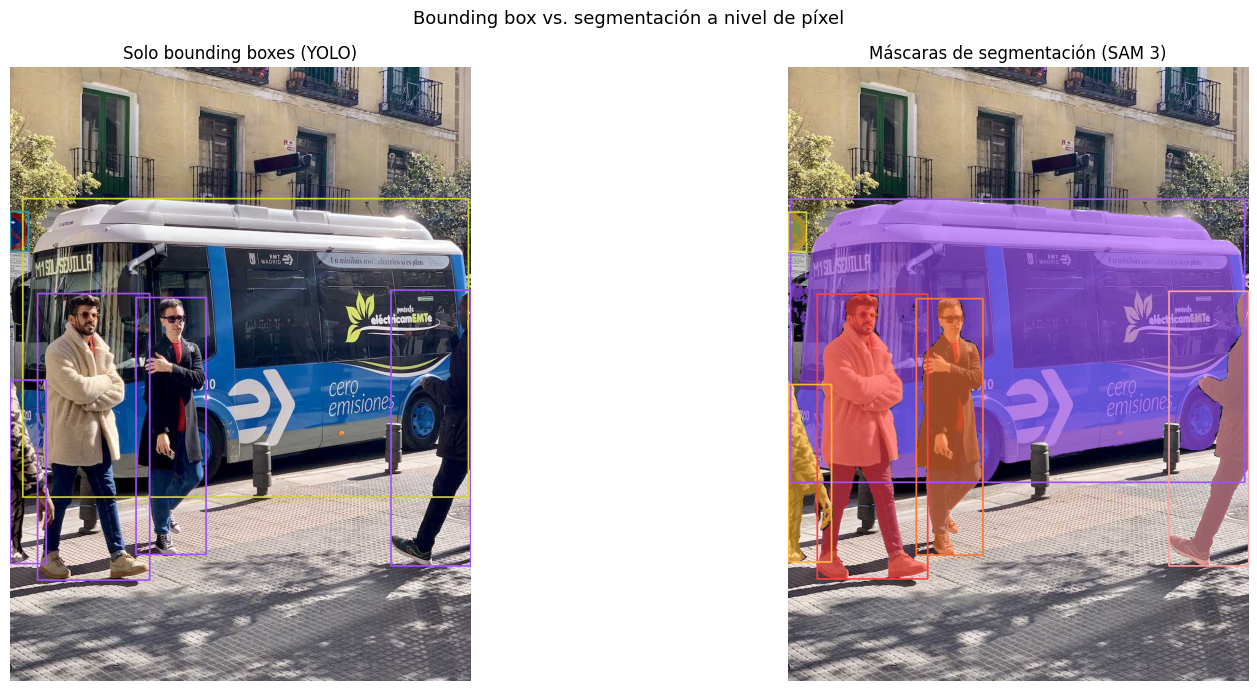

In [6]:
mask_annotator = sv.MaskAnnotator(opacity=0.6)
# opacity controla cuánto "tapa" la máscara a la imagen original
# 0.6 → 60% máscara, 40% imagen original visible debajo

annotated_sam = mask_annotator.annotate(scene=image.copy(), detections=sam_detections)
annotated_sam = box_annotator.annotate(scene=annotated_sam, detections=sam_detections)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
ax1.imshow(cv2.cvtColor(scene_yolo, cv2.COLOR_BGR2RGB))
ax1.set_title("Solo bounding boxes (YOLO)")
ax1.axis("off")
ax2.imshow(cv2.cvtColor(annotated_sam, cv2.COLOR_BGR2RGB))
ax2.set_title("Máscaras de segmentación (SAM 3)")
ax2.axis("off")
plt.suptitle("Bounding box vs. segmentación a nivel de píxel", fontsize=13)
plt.tight_layout()
plt.show()


Tipo: <class 'numpy.ndarray'>
Shape: (1080, 810)
Valores: [False  True]
Píxeles del objeto: 32911
Píxeles totales:    874800


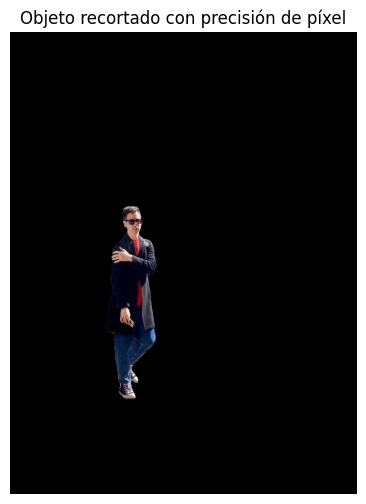

In [7]:
if sam_detections.mask is not None:
    primera_mascara = sam_detections.mask[3]  # máscara del primer objeto
    
    print(f"Tipo: {type(primera_mascara)}")
    print(f"Shape: {primera_mascara.shape}")     # (alto, ancho) — del tamaño de la imagen
    print(f"Valores: {np.unique(primera_mascara)}")  # solo True y False
    print(f"Píxeles del objeto: {primera_mascara.sum()}")
    print(f"Píxeles totales:    {primera_mascara.size}")
    
    # Recortar solo el objeto usando la máscara como "molde"
    objeto_recortado = image.copy()
    # ~ invierte la máscara: ponemos en negro todos los píxeles que NO son el objeto
    objeto_recortado[~primera_mascara] = 0
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(objeto_recortado, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Objeto recortado con precisión de píxel")
    plt.show()

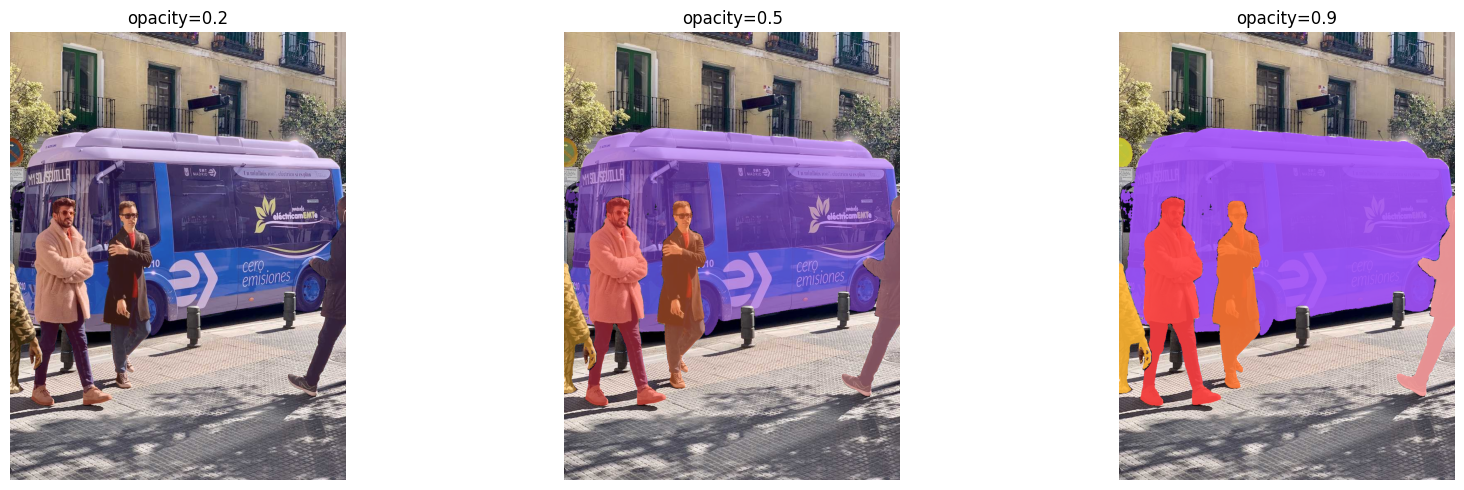

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, opacity in zip(axes, [0.2, 0.5, 0.9]):
    ann = sv.MaskAnnotator(opacity=opacity)
    scene = ann.annotate(scene=image.copy(), detections=sam_detections)
    ax.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
    ax.set_title(f"opacity={opacity}")
    ax.axis("off")
plt.tight_layout()
plt.show()
# 💭 Reflexión: ¿Cuándo conviene alta opacidad? ¿Cuándo baja?
# Alta opacidad → máscaras más visibles, objeto menos legible debajo.
# Baja opacidad → se ve el objeto original, pero la segmentación es menos clara.

Personas detectadas: 4

WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
0: 1036x1036 1 0, 1 1, 1 2, 1 3, 46941.2ms
Speed: 46.0ms preprocess, 46941.2ms inference, 14.2ms postprocess per image at shape (1, 3, 1036, 1036)


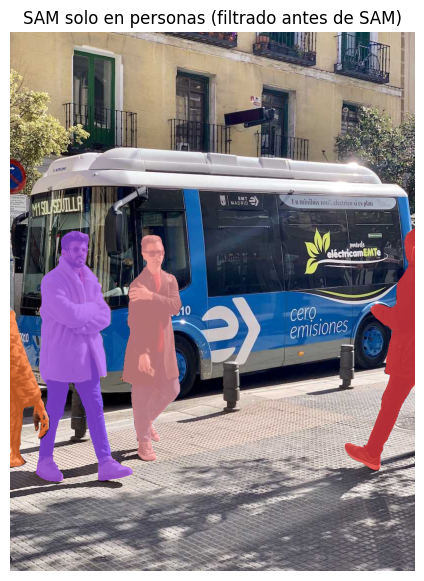

In [9]:
# Filtrar antes de SAM para segmentar solo personas (clase 0)
# Combina filtrado (NB03) con segmentación
solo_personas = yolo_detections[yolo_detections.class_id == 0]
print(f"Personas detectadas: {len(solo_personas)}")

if len(solo_personas) > 0:
    bboxes_personas = solo_personas.xyxy.tolist()
    sam_personas_results = sam_model(image, bboxes=bboxes_personas)[0]
    det_personas = sv.Detections.from_ultralytics(sam_personas_results)
    
    scene = sv.MaskAnnotator(opacity=0.7).annotate(scene=image.copy(), detections=det_personas)
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("SAM solo en personas (filtrado antes de SAM)")
    plt.show()
# 💭 Reflexión: ¿Por qué filtramos antes de SAM en lugar de después?
# SAM es más lento que YOLO — procesar menos objetos ahorra tiempo de cómputo.


0: 384x640 2 persons, 1 tie, 100.3ms
Speed: 17.1ms preprocess, 100.3ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

WARNING imgsz=[1024] must be multiple of max stride 14, updating to [1036]
0: 1036x1036 1 0, 1 1, 1 2, 46107.3ms
Speed: 17.1ms preprocess, 46107.3ms inference, 9.4ms postprocess per image at shape (1, 3, 1036, 1036)


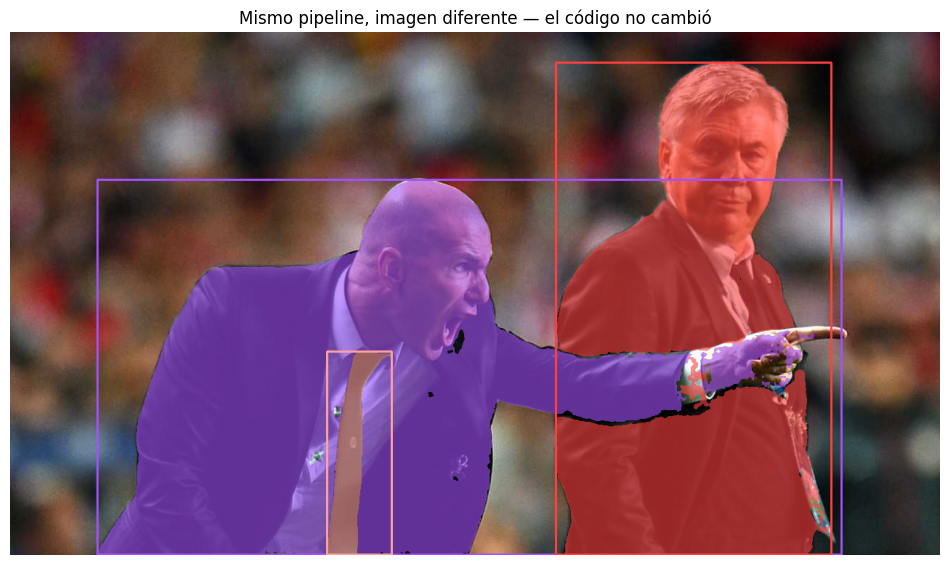

In [10]:
# Cargamos una imagen completamente diferente
image2 = cv2.imread("assets/zidane.jpg")

# El pipeline es IDÉNTICO al de bus.jpg — no cambia ni una línea
yolo_results2  = yolo_model(image2)[0]
yolo_det2      = sv.Detections.from_ultralytics(yolo_results2)
bboxes2        = yolo_det2.xyxy.tolist()
sam_results2   = sam_model(image2, bboxes=bboxes2)[0]
sam_det2       = sv.Detections.from_ultralytics(sam_results2)

annotated2 = sv.MaskAnnotator(opacity=0.6).annotate(scene=image2.copy(), detections=sam_det2)
annotated2 = box_annotator.annotate(scene=annotated2, detections=sam_det2)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Mismo pipeline, imagen diferente — el código no cambió")
plt.show()
# 💭 Reflexión: ¿Necesitaste cambiar algo del pipeline para esta imagen?
# No — Supervision abstrajo la diferencia. Eso es exactamente lo que hace.

66.9%
48.0%
31.0%
62.4%
45.2%
85.1%
['Clase bus: 66.9%', 'Clase person: 48.0%', 'Clase person: 31.0%', 'Clase person: 62.4%', 'Clase person: 45.2%', 'Clase stop sign: 85.1%']


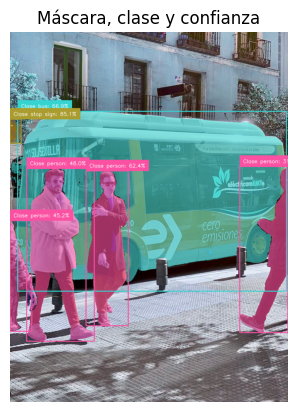

In [27]:
label_annotator = sv.LabelAnnotator()
labels = []
if yolo_detections.class_id is not None:
    sam_detections.class_id = yolo_detections.class_id
    
if sam_detections.mask is not None:
    for i in range(len(sam_detections)):
        area_mascara = sam_detections.mask[i].sum()          # píxeles True en la máscara
        area_caja    = sam_detections.box_area[i]            # (x2-x1) × (y2-y1) en píxeles
        porcentaje   = area_mascara / area_caja * 100        # completa esta línea
        etiqueta     = f"{porcentaje:.1f}%"         # puedes cambiar el formato
        id_actual = yolo_detections.class_id[i]
        clase = yolo_results.names[id_actual] if sam_detections.class_id is not None else "?"
        label = f'Clase {clase}: {etiqueta}'
        labels.append(label)
        print(etiqueta)
    print(labels)
annotated = mask_annotator.annotate(scene=image.copy(), detections=sam_detections)
annotated = box_annotator.annotate(scene=annotated, detections=yolo_detections)
annotated = label_annotator.annotate(scene=annotated, detections=yolo_detections, labels=labels)
plt.figure()
plt.title('Máscara, clase y confianza')
plt.axis('off')
plt.imshow(annotated)

In [28]:
import json, base64
import numpy as np

def detections_to_dict_with_masks(detections, class_names=None):
    """Convierte sv.Detections (con máscaras) a un dict JSON-compatible."""
    data = {
        "xyxy":        detections.xyxy.tolist(),
        "confidence":  detections.confidence.tolist() if detections.confidence is not None else None,
        "class_id":    detections.class_id.tolist()   if detections.class_id   is not None else None,
        "class_names": [class_names[c] for c in detections.class_id]
                       if (class_names and detections.class_id is not None) else None,
    }
    if detections.mask is not None:
        H, W = detections.mask.shape[1:]
        data["mask_shape"] = [H, W]
        # Cada máscara se comprime con packbits y se codifica en base64
        data["masks_b64"] = [
            base64.b64encode(np.packbits(m.flatten()).tobytes()).decode()
            for m in detections.mask
        ]
    return data

resultado = detections_to_dict_with_masks(sam_detections, class_names=yolo_results.names)

with open("assets/predicciones/predicciones_mascaras.json", "w", encoding="utf-8") as f:
    json.dump(resultado, f, indent=2, ensure_ascii=False)

print(f"Guardado: assets/predicciones/predicciones_mascaras.json")
print(f"  {len(sam_detections)} objetos | máscaras de {resultado.get('mask_shape', 'N/A')}")

# Para recuperar una máscara:
# H, W = resultado["mask_shape"]
# raw  = np.frombuffer(base64.b64decode(resultado["masks_b64"][0]), dtype=np.uint8)
# mask = np.unpackbits(raw)[:H*W].reshape(H, W).astype(bool)

Guardado: assets/predicciones/predicciones_mascaras.json
  6 objetos | máscaras de [1080, 810]
